In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/MuffinVsChihuahua'))

['archive.zip']


In [ ]:
!unzip "/content/drive/MyDrive/MuffinVsChihuahua/archive.zip"

Streaming output truncated to the last 5000 lines.
  inflating: test/muffin/img_2_671.jpg  
  inflating: test/muffin/img_2_681.jpg  
  inflating: test/muffin/img_2_689.jpg  
  inflating: test/muffin/img_2_709.jpg  
  inflating: test/muffin/img_2_721.jpg  
  inflating: test/muffin/img_2_73.jpg  
  inflating: test/muffin/img_2_735.jpg  
  inflating: test/muffin/img_2_752.jpg  
  inflating: test/muffin/img_2_757.jpg  
  inflating: test/muffin/img_2_762.jpg  
  inflating: test/muffin/img_2_767.jpg  
  inflating: test/muffin/img_2_78.jpg  
  inflating: test/muffin/img_2_784.jpg  
  inflating: test/muffin/img_2_799.jpg  
  inflating: test/muffin/img_2_8.jpg  
  inflating: test/muffin/img_2_810.jpg  
  inflating: test/muffin/img_2_819.jpg  
  inflating: test/muffin/img_2_82.jpg  
  inflating: test/muffin/img_2_821.jpg  
  inflating: test/muffin/img_2_824.jpg  
  inflating: test/muffin/img_2_827.jpg  
  inflating: test/muffin/img_2_838.jpg  
  inflating: test/muffin/img_2_857.jpg  
  inflating

In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'train', 'test', 'sample_data']


In [ ]:
print(os.listdir("train"))
print(os.listdir("test"))

['chihuahua', 'muffin']
['chihuahua', 'muffin']


In [ ]:
import os

train_chihuahua = len(os.listdir("train/chihuahua"))
train_muffin = len(os.listdir("train/muffin"))

test_chihuahua = len(os.listdir("test/chihuahua"))
test_muffin = len(os.listdir("test/muffin"))

print("Train Chihuahua:", train_chihuahua)
print("Train Muffin:", train_muffin)
print("Test Chihuahua:", test_chihuahua)
print("Test Muffin:", test_muffin)

Train Chihuahua: 2559
Train Muffin: 2174
Test Chihuahua: 640
Test Muffin: 544


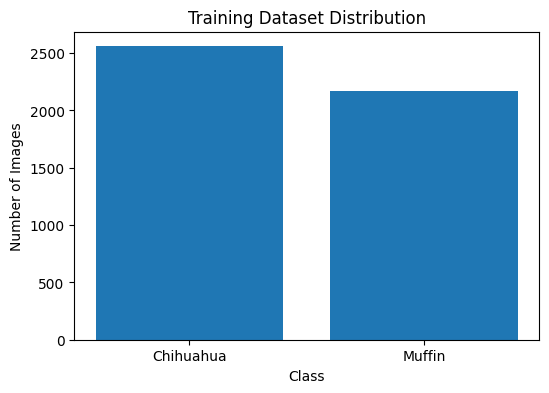

In [ ]:
import matplotlib.pyplot as plt

labels = ['Chihuahua', 'Muffin']
counts = [2559, 2174]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)

plt.title("Training Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

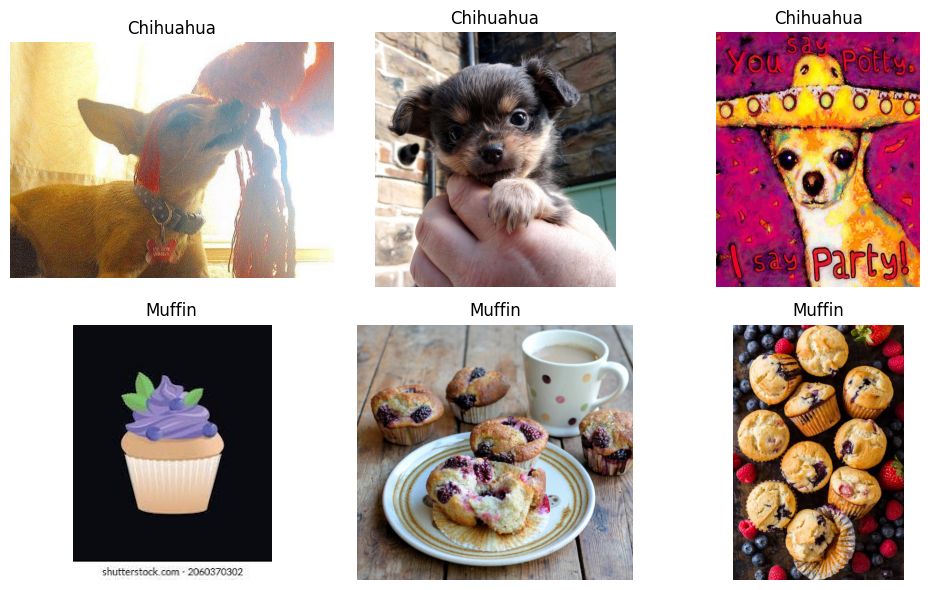

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2,3, figsize=(10,6))

for i,img_name in enumerate(os.listdir("train/chihuahua")[:3]):
    img = Image.open(os.path.join("train/chihuahua",img_name))
    axes[0,i].imshow(img)
    axes[0,i].set_title("Chihuahua")
    axes[0,i].axis("off")

for i,img_name in enumerate(os.listdir("train/muffin")[:3]):
    img = Image.open(os.path.join("train/muffin",img_name))
    axes[1,i].imshow(img)
    axes[1,i].set_title("Muffin")
    axes[1,i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import os

sample_img = os.listdir("train/chihuahua")[0]

img = Image.open(
    os.path.join("train/chihuahua", sample_img)
)

print("Image Size:", img.size)

Image Size: (589, 430)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.


In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1184 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [ ]:
cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 90s 688ms/step - accuracy: 0.6629 - loss: 0.6344 - val_accuracy: 0.8127 - val_loss: 0.4366
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 628ms/step - accuracy: 0.8171 - loss: 0.4284 - val_accuracy: 0.8751 - val_loss: 0.3292
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 626ms/step - accuracy: 0.8176 - loss: 0.4298 - val_accuracy: 0.8646 - val_loss: 0.3345
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 634ms/step - accuracy: 0.8339 - loss: 0.3870 - val_accuracy: 0.8995 - val_loss: 0.2829
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 74s 620ms/step - accuracy: 0.8532 - loss: 0.3577 - val_accuracy: 0.9005 - val_loss: 0.2515


In [ ]:
print(type(cnn_model))

<class 'keras.src.models.sequential.Sequential'>


In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.8682 - loss: 0.2967
Test Accuracy: 0.8682432174682617
Test Loss: 0.296656996011734


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
predictions = cnn_model.predict(test_generator)
pred_classes = (predictions > 0.5).astype(int)

37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 146ms/step


In [ ]:
cm = confusion_matrix(
    test_generator.classes,
    pred_classes
)

print(cm)

[[545  95]
 [ 61 483]]


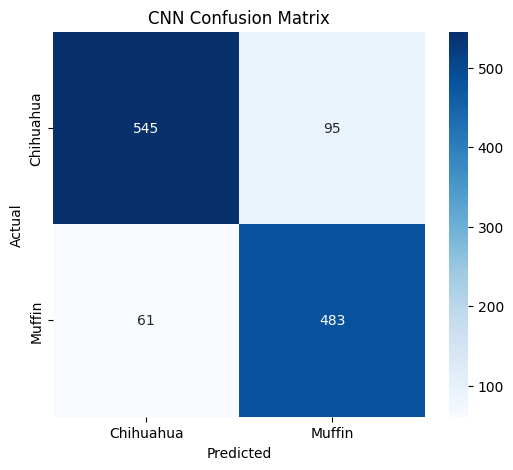

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Chihuahua','Muffin'],
    yticklabels=['Chihuahua','Muffin']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.savefig("cnn_confusion_matrix.png")
plt.show()

In [ ]:
print(
    classification_report(
        test_generator.classes,
        pred_classes,
        target_names=['Chihuahua','Muffin']
    )
)

              precision    recall  f1-score   support

   Chihuahua       0.90      0.85      0.87       640
      Muffin       0.84      0.89      0.86       544

    accuracy                           0.87      1184
   macro avg       0.87      0.87      0.87      1184
weighted avg       0.87      0.87      0.87      1184



In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
mobilenet_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

mobilenet_base.trainable = False

mobilenet_model = Sequential([
    mobilenet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 118s 840ms/step - accuracy: 0.9704 - loss: 0.0721 - val_accuracy: 0.9894 - val_loss: 0.0392
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 595ms/step - accuracy: 0.9894 - loss: 0.0295 - val_accuracy: 0.9915 - val_loss: 0.0305
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 594ms/step - accuracy: 0.9918 - loss: 0.0281 - val_accuracy: 0.9905 - val_loss: 0.0239
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 70s 591ms/step - accuracy: 0.9950 - loss: 0.0145 - val_accuracy: 0.9884 - val_loss: 0.0419
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 599ms/step - accuracy: 0.9955 - loss: 0.0126 - val_accuracy: 0.9915 - val_loss: 0.0305


In [ ]:
test_loss, test_acc = mobilenet_model.evaluate(test_generator)

print("MobileNetV2 Test Accuracy:", test_acc)
print("MobileNetV2 Test Loss:", test_loss)

37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - accuracy: 0.9932 - loss: 0.0197
MobileNetV2 Test Accuracy: 0.9932432174682617
MobileNetV2 Test Loss: 0.019737208262085915


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

pred_probs = mobilenet_model.predict(test_generator)

predictions = (pred_probs > 0.5).astype(int)

cm = confusion_matrix(
    test_generator.classes,
    predictions
)

print(cm)

print(
    classification_report(
        test_generator.classes,
        predictions,
        target_names=["Chihuahua","Muffin"]
    )
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step
[[637   3]
 [  5 539]]
              precision    recall  f1-score   support

   Chihuahua       0.99      1.00      0.99       640
      Muffin       0.99      0.99      0.99       544

    accuracy                           0.99      1184
   macro avg       0.99      0.99      0.99      1184
weighted avg       0.99      0.99      0.99      1184



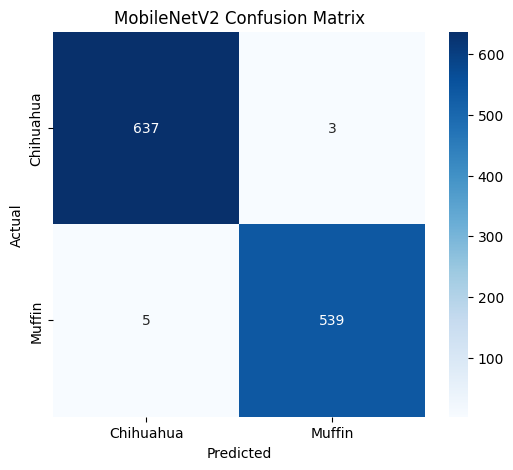

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Chihuahua","Muffin"],
    yticklabels=["Chihuahua","Muffin"]
)

plt.title("MobileNetV2 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("mobilenet_confusion_matrix.png")

plt.show()

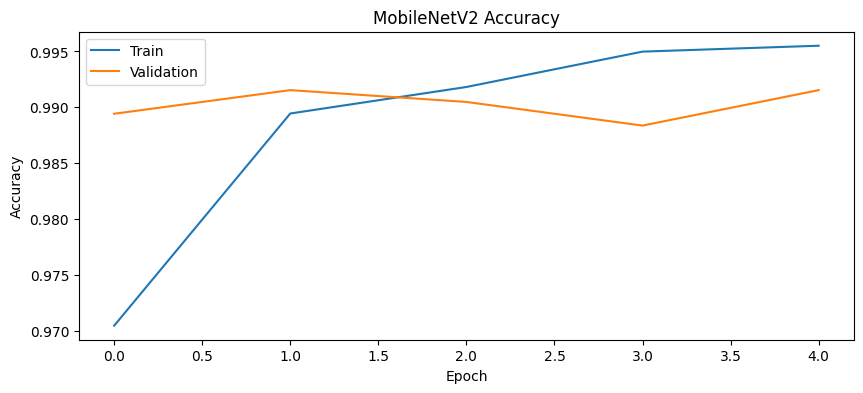

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.savefig("mobilenet_accuracy.png")

plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

resnet_base.trainable = False

resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

resnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 112s 823ms/step - accuracy: 0.6642 - loss: 0.6175 - val_accuracy: 0.7630 - val_loss: 0.5021
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 85s 711ms/step - accuracy: 0.7350 - loss: 0.5493 - val_accuracy: 0.7841 - val_loss: 0.4868
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 694ms/step - accuracy: 0.7273 - loss: 0.5499 - val_accuracy: 0.7757 - val_loss: 0.4804
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 83s 700ms/step - accuracy: 0.7466 - loss: 0.5265 - val_accuracy: 0.8000 - val_loss: 0.4671
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 78s 656ms/step - accuracy: 0.7590 - loss: 0.5179 - val_accuracy: 0.8063 - val_loss: 0.4432


In [ ]:
test_loss, test_acc = resnet_model.evaluate(test_generator)

print("ResNet50 Test Accuracy:", test_acc)
print("ResNet50 Test Loss:", test_loss)

37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 255ms/step - accuracy: 0.7905 - loss: 0.4630
ResNet50 Test Accuracy: 0.7905405163764954
ResNet50 Test Loss: 0.4629972279071808


In [ ]:
pred_probs = resnet_model.predict(test_generator)

predictions = (pred_probs > 0.5).astype(int)

37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 170ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    test_generator.classes,
    predictions
)

print(cm)

print(
    classification_report(
        test_generator.classes,
        predictions,
        target_names=["Chihuahua","Muffin"]
    )
)

[[515 125]
 [123 421]]
              precision    recall  f1-score   support

   Chihuahua       0.81      0.80      0.81       640
      Muffin       0.77      0.77      0.77       544

    accuracy                           0.79      1184
   macro avg       0.79      0.79      0.79      1184
weighted avg       0.79      0.79      0.79      1184



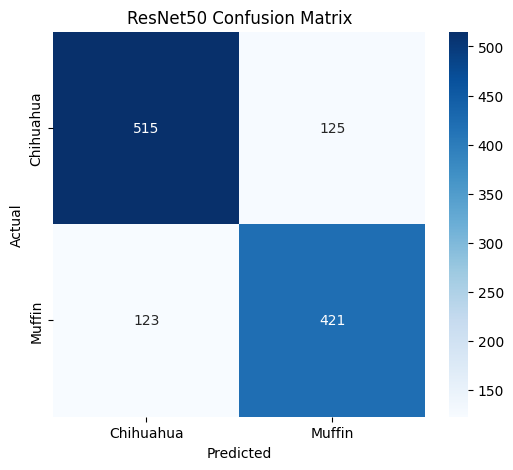

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Chihuahua","Muffin"],
    yticklabels=["Chihuahua","Muffin"]
)

plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("resnet_confusion_matrix.png")

plt.show()

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

In [ ]:
efficientnet_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

efficientnet_base.trainable = False

efficientnet_model = Sequential([
    efficientnet_base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

efficientnet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 144s 948ms/step - accuracy: 0.5074 - loss: 0.7056 - val_accuracy: 0.5407 - val_loss: 0.6919
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 75s 632ms/step - accuracy: 0.5306 - loss: 0.6917 - val_accuracy: 0.5407 - val_loss: 0.6899
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 641ms/step - accuracy: 0.5354 - loss: 0.6913 - val_accuracy: 0.5407 - val_loss: 0.6906
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 76s 639ms/step - accuracy: 0.5407 - loss: 0.6914 - val_accuracy: 0.5407 - val_loss: 0.6903
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 84s 659ms/step - accuracy: 0.5407 - loss: 0.6905 - val_accuracy: 0.5407 - val_loss: 0.6901


In [ ]:
test_loss, test_acc = efficientnet_model.evaluate(test_generator)

print("EfficientNetB0 Test Accuracy:", test_acc)
print("EfficientNetB0 Test Loss:", test_loss)

37/37 ━━━━━━━━━━━━━━━━━━━━ 25s 214ms/step - accuracy: 0.4595 - loss: 0.7061
EfficientNetB0 Test Accuracy: 0.45945945382118225
EfficientNetB0 Test Loss: 0.7060932517051697


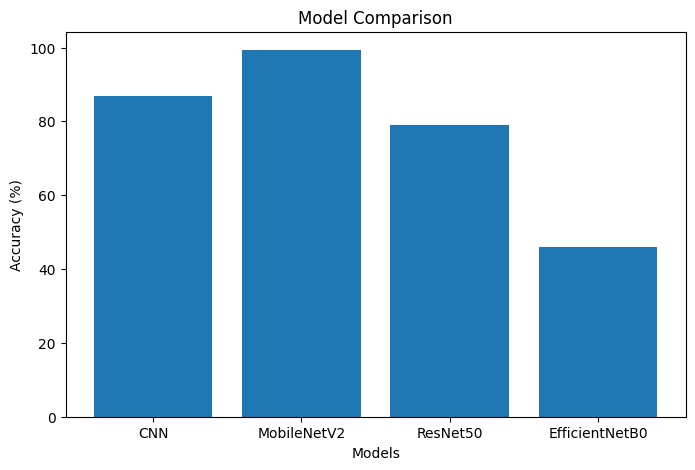

In [ ]:
import matplotlib.pyplot as plt

models = [
    "CNN",
    "MobileNetV2",
    "ResNet50",
    "EfficientNetB0"
]

accuracies = [
    86.82,
    99.32,
    79.05,
    45.95
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Model Comparison")

plt.savefig("model_comparison.png")

plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 174ms/step


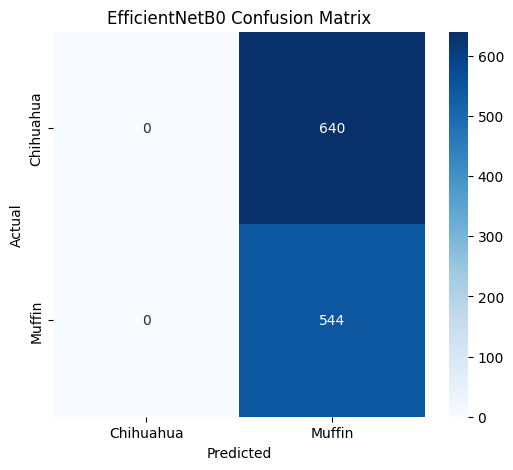

[[  0 640]
 [  0 544]]
              precision    recall  f1-score   support

   Chihuahua       0.00      0.00      0.00       640
      Muffin       0.46      1.00      0.63       544

    accuracy                           0.46      1184
   macro avg       0.23      0.50      0.31      1184
weighted avg       0.21      0.46      0.29      1184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pred = efficientnet_model.predict(test_generator)
pred = (pred > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Chihuahua','Muffin'],
            yticklabels=['Chihuahua','Muffin'])

plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("efficientnet_confusion_matrix.png")
plt.show()

print(cm)
print(classification_report(test_generator.classes,pred,target_names=['Chihuahua','Muffin']))